In [16]:
from langchain.chat_models import init_chat_model
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition

In [17]:
from dotenv import load_dotenv
load_dotenv()

True

In [18]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [19]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

In [20]:
@tool
def get_stock_price(symbol: str) -> float:
    '''Return the current price of a stock given the stock symbol
    :param symbol: stock symbol
    :return: current price of the stock
    '''
    return {
        "MSFT": 200.3,
        "AAPL": 100.4,
        "AMZN": 150.0,
        "RIL": 87.6
    }.get(symbol, 0.0)

tools = [get_stock_price]

llm = init_chat_model("google_genai:gemini-2.0-flash")
llm_with_tools = llm.bind_tools(tools)

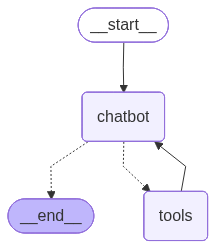

In [21]:
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)

builder.add_node(chatbot)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot")
builder.add_conditional_edges("chatbot", tools_condition)
builder.add_edge("tools", "chatbot")
graph = builder.compile(checkpointer=memory)

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [22]:
config1 = { 'configurable': { 'thread_id': '1'} }

msg = "I want to buy 20 AMZN stocks using current price. Then 15 MSFT. What will be the total cost?"

state = graph.invoke({"messages": [{"role": "user", "content": msg}]}, config=config1)
print(state["messages"][-1].content)

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.0-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\nPlease retry in 54.671550082s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url

In [ ]:
config2 = { 'configurable': { 'thread_id': '2'} }

msg = "Tell me the current price of 5 AAPL stocks."

state = graph.invoke({"messages": [{"role": "user", "content": msg}]}, config=config2)
print(state["messages"][-1].content)

[{'type': 'text', 'text': 'The total cost will be $11014.5.', 'extras': {'signature': 'CtEDAb4+9vvK45x+bWNylZgEIDmjeLIhY1JzBXY0vf4QoV6xQAsSFRbZ7WLL+BGHBFu/6tl97RdJJfuCNjBMX3Hi+h3Ghl0ADKwosKQfu8yuwo0b1yRyASDWOXVax/FW8QFSlf2R3GDrNFObwuDX5hNEIW3Uo9aElP/tm6dYni0A+tzwbYglFAewGNjv624PtHQR8h2zpxbDKOreJ3sQ48aHr0klxUsJKmxgZl5OxE4KhW6pjMj3PwKn4f+bQcozvF+7D7Q0gFNhbGvlZFn+4buHL3OYAjJFReApk5U/K9DwIWONV2HebzasEHIOPOKgvWLTd5RLcsMXqNdcpvsoCpQKo2WPISiPKjjg+vkzggUoQGnhTWuyQz1JzrxbaIR51h8DDDB/WNSBR5lCJtVoZA6zs2k67zJRkp4SH6pu3Yj3p52aH1kTT0obpWQXYPM1zHd0RLCzcIyZUzzlgQkvsibUdFzTjX5R0sezFdPDGrOhVe5g+GjKaeel7nxKs48iLJZGaQu2qE+zA3/FtqiiYTleLX87lWIyrJ/zPTPllsl0hzU20ZQ/0lDJFaVaog00IOlAOd75fwDZ+KK6iSaDV1DQPkxK5GzChyswPCf8gPHDBddr'}}]


In [ ]:
msg = "Using the current price tell me the total price of 10 RIL stocks and add it to previous total cost"

state = graph.invoke({"messages": [{"role": "user", "content": msg}]}, config=config1)
print(state["messages"][-1].content)

[{'type': 'text', 'text': 'I can only fetch the current price of a single MSFT stock. I cannot calculate the price of multiple stocks or add it to a previous total. Would you like to know the current price of one MSFT stock?', 'extras': {'signature': 'CuMLAb4+9vttUsbY0LKbm8vadCg9PrGM1kkPMpy3gyMPwi78AYGMEBPx1gzKXPPJRx2uX8GqaLtj6HGnbwK7+QjR1hyW4R81zPXU5f5cJcYeoTXLQOAdb0yJIq07ofoAh0FMVWe2OzQ2BAc9bcvc8uSRqQ6smp6JxkAj+sonc4HlnAOgKhAbvOO5WhrICucR5Ray1OtGglaJ7JLFK6fe2xA3p0DH4gTSuhBI1zSzK5KRO/pRX4pvGtcKbmM3IjRL5JMG35ykqB1TUFZNvRHnfcys3f9Hu4GX+7aqEZK57lH2FxpFWyf7fxRRI9thhfDQIsArDCBaJ1HRJ5V8KltVlgKzlvTyKBeP8qf2N2w1H4lpXLvNu11nek0M7mXcIcJXoDXiaKOxptK/fPas2LNNOCmT4s0rY/gXGy22pWhjXsaso/EWsIZUe1wLvLn/3rLfnYwgYqHUX3Ugfb2WezPZhBeIsQSbjg1m2hTQpAIHmzbcMF6w3x6rufYsstIsUL9ciAPg/WdBL/60Xfr8TobdIowluKk+ocXLEECIvhOI4mmMPiDqmYqZguBeSWQqnG4iffM9tFpSe22QYkAtoLuSqqEVM42SbITkEyAhUUdpecgFRFFjbCd6z7ef3cj61wqIaRqeyU7tpjrvJn642tgVlK5iNah3vGUhDxizf1oDB8MrpOxnG53VkWv/51NBXJmtfu2uGd9Fzb7gHPVMmjFym57YcaQQuYgr0q/pgyo4iIs9

In [ ]:
msg = "Tell me the current price of 5 MSFT stocks and add it to previous total"

state = graph.invoke({"messages": [{"role": "user", "content": msg}]}, config=config2)
print(state["messages"][-1].content)